In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone, timedelta
from scipy.signal import butter, filtfilt
import seisbench.models as sbm
from obspy import Stream, Trace, UTCDateTime
from matplotlib.lines import Line2D
import pandas as pd

OMP: Warning #80: OMP_NUM_THREADS="0": value too small.
OMP: Info #104: OMP_NUM_THREADS value "1" will be used.

libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
H5_PATH   = '/root/autodl-tmp/Test_on_Event/menyuan/Menyuan/Menyuan.h5'
COMPONENT = 'UD'
HALF_DEG  = 0.75
T_WINDOW  = (-5, 60)
SCALE     = 0.8
FREQ_BAND = (1.0, 10.0)

# Menyuan origin time in UTC
MANUAL_ORIGIN_TIMES = {
    'Menyuan': '2022-01-07T17:45:30+00:00',
}

ASSUME_CST              = True    # recorder_time stored in CST (UTC+8)
EVENT_NAME              = H5_PATH.split('/')[-2]
PHASENET_PROB_THRESHOLD = 0.3
PHASENET_CACHE_PATH     = Path(H5_PATH).parent / f'{EVENT_NAME}_phasenet_picks.csv'
V_P_KM_S               = 6.0
T_P_TOLERANCE_S        = 3.0

FAULT_LENGTH_A        = 0.50
FAULT_LENGTH_B        = -1.80
RUPTURE_VELOCITY_KM_S = 3.0
PHYSICAL_END_BUFFER_S = 4.0
V_S_KM_S              = 3.5

In [3]:
CST = timezone(timedelta(hours=8))


def parse_time(s, assume_cst=False):
    s = str(s)
    if s.endswith('Z'):
        s = s[:-1] + '+00:00'
    try:
        dt = datetime.fromisoformat(s)
    except ValueError:
        dt = datetime.strptime(s, '%Y-%m-%dT%H:%M:%S')
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=CST if assume_cst else timezone.utc)
    return dt


def bandpass(data, fs, fmin, fmax, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [fmin / nyq, fmax / nyq], btype='band')
    return filtfilt(b, a, data)


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2) ** 2
    return float(R * 2 * np.arcsin(np.sqrt(a)))


def get_rec_offset(grp, ori_time, dist_km, p_pick_abs, assume_cst):
    """
    Compute rec_offset_s = (record_start - origin_time) in seconds.

    Priority:
      1. recorder_time attribute exists and is not UNKNOWN
         -> recorder_time is the hardware trigger time (no pretrigger to subtract)
         -> offset_s = recorder_time - origin_time
         -> t0_utc   = recorder_time  (waveform starts AT trigger)
      2. recorder_time missing/UNKNOWN but PhaseNet pick available
         -> fallback: offset_s = p_pick_abs - dist_km / V_P_KM_S
      3. both missing -> 0.0

    Returns (offset_s, t0_utc_or_None, source_label)
    """
    rec_time_raw = grp.attrs.get('recorder_time', None)

    if rec_time_raw is not None and str(rec_time_raw) not in ('UNKNOWN', ''):
        try:
            rec_time = parse_time(str(rec_time_raw), assume_cst=assume_cst)
            offset_s = (rec_time - ori_time).total_seconds()
            t0_utc   = UTCDateTime(rec_time.timestamp())
            return offset_s, t0_utc, 'recorder_time'
        except Exception:
            pass

    # fallback: derive from PhaseNet pick + theoretical P-wave travel time
    if p_pick_abs is not None:
        t_p_theory = dist_km / V_P_KM_S
        offset_s   = float(p_pick_abs) - t_p_theory
        t0_utc     = UTCDateTime(ori_time.timestamp() + offset_s)
        return offset_s, t0_utc, 'phasenet_fallback'

    return 0.0, None, 'missing'

In [4]:
def run_phasenet(h5_path, origin_times, assume_cst, half_deg, prob_threshold):
    phasenet = sbm.PhaseNet.from_pretrained('stead')
    phasenet.eval()

    event_name = str(h5_path).split('/')[-2]
    picks    = {}
    dist_map = {}

    with h5py.File(h5_path, 'r') as f:
        eq      = f['earthquake']
        epi_lat = float(eq.attrs['latitude'])
        epi_lon = float(eq.attrs['longitude'])
        ori_time = parse_time(
            origin_times[event_name] if event_name in origin_times
            else eq.attrs['origin_time'],
            assume_cst=False,   # origin time is UTC
        )

        for sid, grp in f['stations'].items():
            sta_lat = float(grp.attrs['latitude'])
            sta_lon = float(grp.attrs['longitude'])

            if abs(sta_lat - epi_lat) > half_deg:
                continue
            if abs(sta_lon - epi_lon) > half_deg:
                continue

            dist_km = haversine_km(epi_lat, epi_lon, sta_lat, sta_lon)
            dist_map[sid] = dist_km

            if 'waveforms' not in grp:
                picks[sid] = None
                continue

            sr = float(grp.attrs['sampling_rate'])

            # get t0_utc using recorder_time (no p_pick_abs yet)
            _, t0_utc, _ = get_rec_offset(
                grp, ori_time, dist_km,
                p_pick_abs=None,
                assume_cst=assume_cst,
            )

            if t0_utc is None:
                picks[sid] = None
                continue

            offset_s = (parse_time(str(grp.attrs.get('recorder_time', '')),
                                   assume_cst=assume_cst) - ori_time
                       ).total_seconds() if str(grp.attrs.get(
                           'recorder_time', 'UNKNOWN')) != 'UNKNOWN' else 0.0

            comp_keys = list(grp['waveforms'].keys())
            e_key = next((k for k in ['EW', 'EW1'] if k in comp_keys), None)
            n_key = next((k for k in ['NS', 'NS1'] if k in comp_keys), None)
            u_key = next((k for k in ['UD', 'UD1'] if k in comp_keys), None)

            def load_comp(key):
                if key is None:
                    return None
                return np.asarray(grp['waveforms'][key][:], dtype=np.float32)

            arrs  = [load_comp(k) for k in [e_key, n_key, u_key]]
            valid = [a for a in arrs if a is not None]
            if len(valid) == 0:
                picks[sid] = None
                continue

            min_len = min(len(a) for a in valid)
            st = Stream()
            for arr, cha in zip(arrs, ['HHE', 'HHN', 'HHZ']):
                if arr is None:
                    arr = np.zeros(min_len, dtype=np.float32)
                tr                     = Trace()
                tr.data                = arr[:min_len].astype(np.float64)
                tr.stats.sampling_rate = sr
                tr.stats.starttime     = t0_utc
                tr.stats.network       = 'GS'
                tr.stats.station       = sid[:5]
                tr.stats.channel       = cha
                st.append(tr)

            try:
                anno = phasenet.annotate(st)
            except Exception:
                picks[sid] = None
                continue

            p_traces = [tr for tr in anno if 'P' in tr.stats.channel]
            if len(p_traces) == 0:
                picks[sid] = None
                continue

            p_tr   = p_traces[0]
            p_prob = p_tr.data.astype(np.float32)
            p_sr   = p_tr.stats.sampling_rate
            p_t0   = p_tr.stats.starttime.timestamp - t0_utc.timestamp

            above = np.where(p_prob >= prob_threshold)[0]
            if len(above) == 0:
                picks[sid] = None
            else:
                t_in_rec_s = p_t0 + float(above[0]) / p_sr
                picks[sid] = offset_s + t_in_rec_s

    # physical plausibility filter
    n_rejected = 0
    for sid, val in picks.items():
        if val is None:
            continue
        t_p_theory = dist_map.get(sid, 0.0) / V_P_KM_S
        t_min = max(0.0, t_p_theory - T_P_TOLERANCE_S)
        t_max = t_p_theory + T_P_TOLERANCE_S
        if val < t_min or val > t_max:
            picks[sid] = None
            n_rejected += 1

    # fill remaining None with theoretical P-wave arrival
    n_phasenet = sum(1 for v in picks.values() if v is not None)
    n_fallback = 0
    for sid, val in picks.items():
        if val is None and sid in dist_map:
            picks[sid] = dist_map[sid] / V_P_KM_S
            n_fallback += 1

    print(f'PhaseNet picks: {n_phasenet} | rejected: {n_rejected} | '
          f'theoretical fallback: {n_fallback}')
    return picks, dist_map


def load_or_compute_picks(h5_path, cache_path, origin_times,
                           assume_cst, half_deg, prob_threshold):
    if cache_path.exists():
        df    = pd.read_csv(cache_path, index_col='station_id')
        picks = {
            sid: (None if pd.isna(row['p_pick_s']) else float(row['p_pick_s']))
            for sid, row in df.iterrows()
        }
        print(f'Loaded picks from cache: {len(picks)} stations')
    else:
        print('Running PhaseNet ...')
        picks, dist_map = run_phasenet(
            h5_path, origin_times, assume_cst, half_deg, prob_threshold,
        )
        rows = []
        for sid, val in picks.items():
            dist_km     = dist_map.get(sid, np.nan)
            theoretical = dist_km / V_P_KM_S if not np.isnan(dist_km) else np.nan
            is_fallback = (val is not None) and (
                not np.isnan(theoretical) and abs(val - theoretical) < 0.01
            )
            rows.append({
                'station_id':      sid,
                'p_pick_s':        val if val is not None else np.nan,
                'dist_km':         dist_km,
                'theoretical_p_s': theoretical,
                'source':          'theoretical' if is_fallback else 'phasenet',
            })
        pd.DataFrame(rows).to_csv(cache_path, index=False)
        print(f'Picks saved to {cache_path}')
    return picks

In [5]:
picks = load_or_compute_picks(
    Path(H5_PATH), PHASENET_CACHE_PATH,
    MANUAL_ORIGIN_TIMES, ASSUME_CST, HALF_DEG,
    PHASENET_PROB_THRESHOLD,
)

Loaded picks from cache: 60 stations


In [6]:
records = []

with h5py.File(H5_PATH, 'r') as f:
    eq      = f['earthquake']
    epi_lat = float(eq.attrs['latitude'])
    epi_lon = float(eq.attrs['longitude'])
    mag     = float(eq.attrs['magnitude'])
    ori_time = parse_time(
        MANUAL_ORIGIN_TIMES[EVENT_NAME] if EVENT_NAME in MANUAL_ORIGIN_TIMES
        else eq.attrs['origin_time'],
        assume_cst=False,   # origin time is UTC
    )

    for sid, grp in f['stations'].items():
        if COMPONENT not in grp.get('waveforms', {}):
            continue

        sta_lat = float(grp.attrs['latitude'])
        sta_lon = float(grp.attrs['longitude'])

        if abs(sta_lat - epi_lat) > HALF_DEG:
            continue
        if abs(sta_lon - epi_lon) > HALF_DEG:
            continue

        trigger_abs_s = picks.get(sid, None)
        if trigger_abs_s is None:
            continue

        dist_km = haversine_km(epi_lat, epi_lon, sta_lat, sta_lon)
        sr      = float(grp.attrs['sampling_rate'])
        acc_raw = np.asarray(grp['waveforms'][COMPONENT][:], dtype=np.float32)

        # get offset_s: recorder_time preferred, PhaseNet fallback
        offset_s, _, src = get_rec_offset(
            grp, ori_time, dist_km,
            p_pick_abs=trigger_abs_s,
            assume_cst=ASSUME_CST,
        )

        n = len(acc_raw)
        t = np.arange(n) / sr + offset_s

        try:
            acc_disp = bandpass(acc_raw, sr, FREQ_BAND[0], FREQ_BAND[1]) \
                       if FREQ_BAND and len(acc_raw) > 20 else acc_raw.copy()
        except Exception:
            acc_disp = acc_raw.copy()

        mask = (t >= T_WINDOW[0]) & (t <= T_WINDOW[1])
        if mask.sum() < 10:
            continue

        records.append({
            'sid':        sid,
            'network':    'CSMNC',
            'dist_km':    dist_km,
            'trigger_s':  float(trigger_abs_s),
            'offset_src': src,
            't':          t[mask],
            'acc':        acc_disp[mask],
            'pga':        float(np.max(np.abs(acc_disp[mask]))),
        })

records.sort(key=lambda r: r['trigger_s'])
n_total   = len(records)
triggered = [r for r in records if np.isfinite(r['trigger_s'])]

n_rt  = sum(1 for r in records if r['offset_src'] == 'recorder_time')
n_fb  = sum(1 for r in records if r['offset_src'] == 'phasenet_fallback')
n_mis = sum(1 for r in records if r['offset_src'] == 'missing')
print(f'Stations: {n_total} | P-pick: {len(triggered)}')
print(f'offset source — recorder_time: {n_rt} | phasenet_fallback: {n_fb} | missing: {n_mis}')

Stations: 60 | P-pick: 60
offset source — recorder_time: 59 | phasenet_fallback: 1 | missing: 0


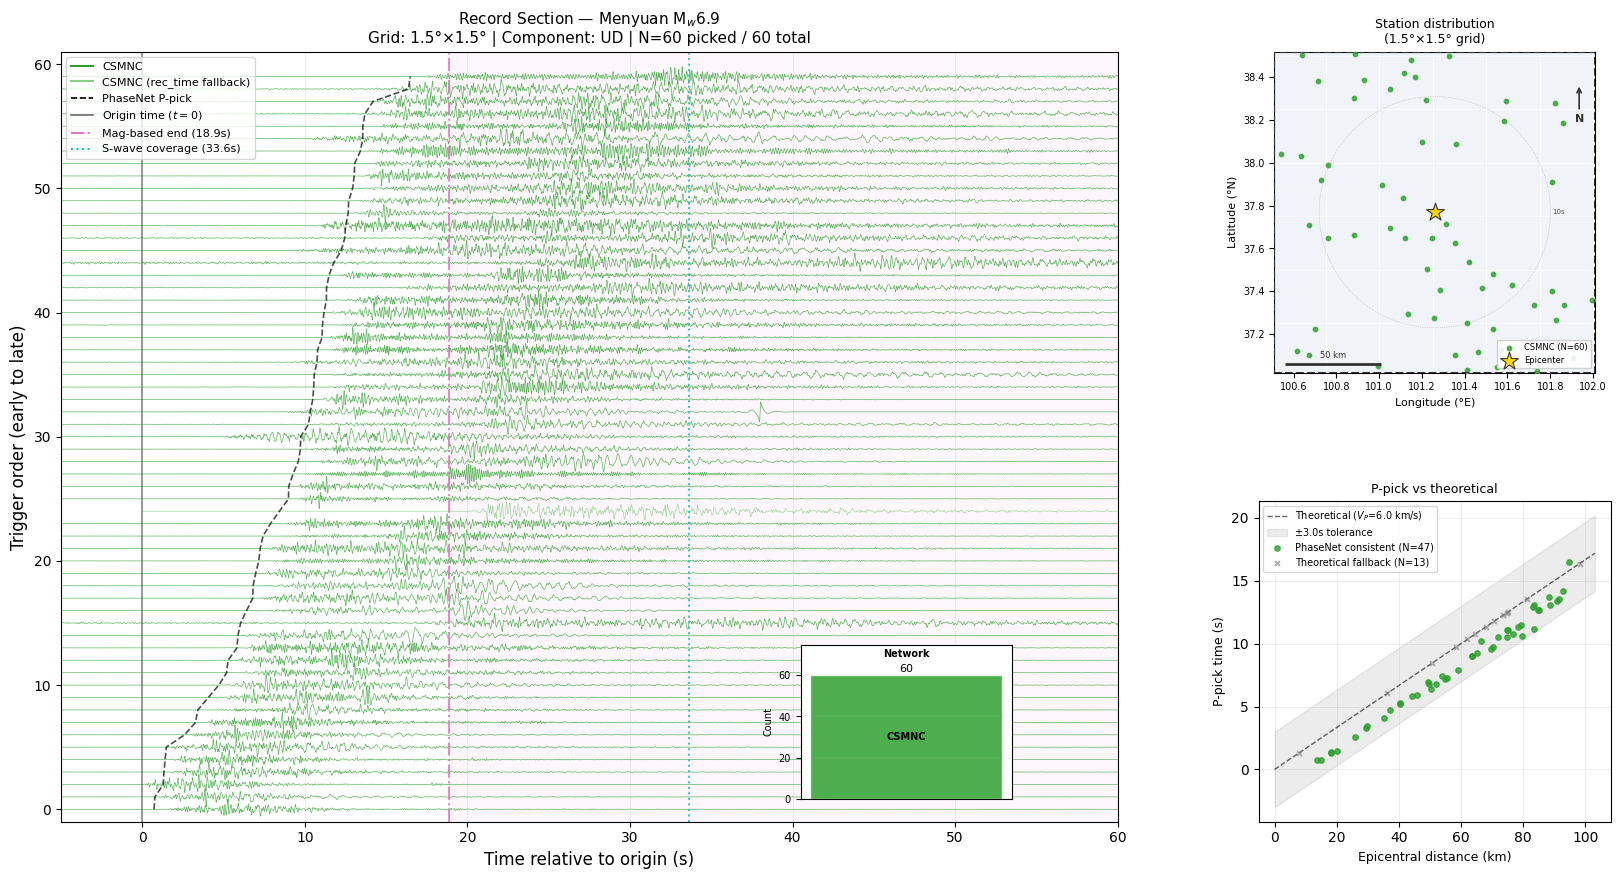

Saved: menyuan_record_section.png


In [7]:
dist_vals = [r['dist_km'] for r in records]

length_km          = 10 ** (FAULT_LENGTH_A * mag + FAULT_LENGTH_B)
rupture_duration_s = length_km / RUPTURE_VELOCITY_KM_S
t_end_mag          = rupture_duration_s + PHYSICAL_END_BUFFER_S
grid_half_diag_km  = HALF_DEG * 111.0 * np.sqrt(2)
t_end_swave        = grid_half_diag_km / V_S_KM_S

fig = plt.figure(figsize=(20, 10))
gs  = fig.add_gridspec(2, 2, width_ratios=[3, 1], hspace=0.4)
ax   = fig.add_subplot(gs[:, 0])
ax_d = fig.add_subplot(gs[0, 1])
ax_r = fig.add_subplot(gs[1, 1])

c_normal   = '#2ca02c'
c_fallback = '#88cc88'
amp_scale  = SCALE

# ── main record section ───────────────────────────────────────────────────────
for rank, rec in enumerate(records):
    pga = rec['pga']
    if pga < 1e-6:
        continue
    color = c_fallback if rec['offset_src'] == 'phasenet_fallback' else c_normal
    ax.plot(rec['t'], rank + rec['acc'] / pga * amp_scale,
            lw=0.5, color=color, alpha=0.75)

if triggered:
    ax.plot(
        [r['trigger_s'] for r in triggered],
        list(range(len(triggered))),
        'k--', lw=1.2, alpha=0.7,
    )

ax.axvline(0, color='dimgray', lw=1.2, alpha=0.8, ls='-')
ax.axvline(t_end_mag,   color='#e377c2', lw=1.5, alpha=0.85, ls='-.')
ax.axvline(t_end_swave, color='#17becf', lw=1.5, alpha=0.85, ls=':')
ax.axvspan(t_end_mag, T_WINDOW[1], alpha=0.06, color='#e377c2')

ax.legend(handles=[
    Line2D([0], [0], color=c_normal,   lw=1.5, label='CSMNC'),
    Line2D([0], [0], color=c_fallback, lw=1.5, label='CSMNC (rec_time fallback)'),
    Line2D([0], [0], color='k',        lw=1.2, ls='--', label='PhaseNet P-pick'),
    Line2D([0], [0], color='dimgray',  lw=1.2, ls='-',  label='Origin time ($t=0$)'),
    Line2D([0], [0], color='#e377c2',  lw=1.5, ls='-.', label=f'Mag-based end ({t_end_mag:.1f}s)'),
    Line2D([0], [0], color='#17becf',  lw=1.5, ls=':',  label=f'S-wave coverage ({t_end_swave:.1f}s)'),
], loc='upper left', fontsize=8)

ax.set_xlabel('Time relative to origin (s)', fontsize=12)
ax.set_ylabel('Trigger order (early to late)', fontsize=12)
ax.set_xlim(T_WINDOW)
ax.set_ylim(-1, n_total + 1)
ax.set_title(
    f'Record Section \u2014 Menyuan M$_w${mag}\n'
    f'Grid: 1.5\u00b0\u00d71.5\u00b0 | Component: {COMPONENT} | '
    f'N={len(triggered)} picked / {n_total} total',
    fontsize=11,
)
ax.grid(axis='x', lw=0.4, alpha=0.4)

# ── inset: station count ──────────────────────────────────────────────────────
ax_inset = ax.inset_axes([0.70, 0.03, 0.20, 0.20])
x_pos = np.arange(1)
ax_inset.bar(x_pos, [n_total], color=c_normal, edgecolor='white', alpha=0.85)
ax_inset.text(0, n_total + 0.5, str(n_total), ha='center', va='bottom', fontsize=8)
ax_inset.text(0, n_total / 2, 'CSMNC', ha='center', va='center',
              fontsize=7, color='black', fontweight='bold')
ax_inset.set_ylim(0, n_total * 1.25)
ax_inset.text(0.5, 0.97, 'Network', ha='center', va='top',
              transform=ax_inset.transAxes, fontsize=7, fontweight='bold')
ax_inset.set_xticks([])
ax_inset.set_ylabel('Count', fontsize=7)
ax_inset.set_title('')
ax_inset.tick_params(labelsize=7)
ax_inset.set_facecolor('white')
ax_inset.patch.set_alpha(1.0)
ax_inset.grid(axis='y', lw=0.3, alpha=0.4)

# ── subplot 1: geographic station distribution ────────────────────────────────
sta_lons, sta_lats = [], []
with h5py.File(H5_PATH, 'r') as f:
    eq_      = f['earthquake']
    epi_lat_ = float(eq_.attrs['latitude'])
    epi_lon_ = float(eq_.attrs['longitude'])
    for sid, grp in f['stations'].items():
        la = float(grp.attrs['latitude'])
        lo = float(grp.attrs['longitude'])
        if abs(la - epi_lat_) <= HALF_DEG and abs(lo - epi_lon_) <= HALF_DEG:
            sta_lats.append(la)
            sta_lons.append(lo)

lon_min = epi_lon - HALF_DEG
lon_max = epi_lon + HALF_DEG
lat_min = epi_lat - HALF_DEG
lat_max = epi_lat + HALF_DEG

ax_d.set_facecolor('#f0f4f8')
for glon in np.arange(np.ceil(lon_min * 4) / 4, lon_max, 0.25):
    ax_d.axvline(glon, color='white', lw=0.6, alpha=0.8, zorder=1)
for glat in np.arange(np.ceil(lat_min * 4) / 4, lat_max, 0.25):
    ax_d.axhline(glat, color='white', lw=0.6, alpha=0.8, zorder=1)
rect = plt.Rectangle(
    (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
    linewidth=1.5, edgecolor='#333333', facecolor='none', linestyle='--', zorder=4,
)
ax_d.add_patch(rect)
ax_d.scatter(sta_lons, sta_lats, s=20, c=c_normal, marker='o',
             alpha=0.85, edgecolors='white', linewidths=0.3, zorder=3,
             label=f'CSMNC (N={len(sta_lons)})')
ax_d.scatter(epi_lon, epi_lat, s=180, c='gold', marker='*',
             edgecolors='#333333', linewidths=0.8, zorder=5, label='Epicenter')
for t_s in [10, 20, 30]:
    r_deg = (V_P_KM_S * t_s) / 111.0
    theta = np.linspace(0, 2 * np.pi, 300)
    cx = epi_lon + r_deg * np.cos(theta)
    cy = epi_lat + r_deg * np.sin(theta)
    ax_d.plot(cx, cy, color='#888888', lw=0.5, ls=':', alpha=0.6, zorder=2)
    if epi_lon + r_deg < lon_max:
        ax_d.text(epi_lon + r_deg + 0.01, epi_lat, f'{t_s}s',
                  fontsize=5, color='#555555', va='center', zorder=4)
ax_d.set_xlim(lon_min, lon_max)
ax_d.set_ylim(lat_min, lat_max)
ax_d.set_xlabel('Longitude (\u00b0E)', fontsize=8)
ax_d.set_ylabel('Latitude (\u00b0N)', fontsize=8)
ax_d.set_title('Station distribution\n(1.5\u00b0\u00d71.5\u00b0 grid)', fontsize=9)
ax_d.tick_params(labelsize=7)
ax_d.set_aspect('equal')
ax_d.legend(fontsize=6, loc='lower right', framealpha=0.9, edgecolor='#cccccc')
ax_d.annotate('N', xy=(0.95, 0.90), xytext=(0.95, 0.78),
              xycoords='axes fraction', textcoords='axes fraction',
              ha='center', fontsize=8, fontweight='bold',
              arrowprops=dict(arrowstyle='->', color='#333333', lw=1.2),
              color='#333333')
scale_deg = 50.0 / 111.0
bar_x0 = lon_min + 0.05
bar_y0 = lat_min + 0.04
ax_d.plot([bar_x0, bar_x0 + scale_deg], [bar_y0, bar_y0],
          color='#333333', lw=2.0, solid_capstyle='butt', zorder=5)
ax_d.text(bar_x0 + scale_deg / 2, bar_y0 + 0.02, '50 km',
          ha='center', va='bottom', fontsize=6, color='#333333', zorder=5)

# ── subplot 2: P-pick consistency ─────────────────────────────────────────────
df_picks = pd.read_csv(PHASENET_CACHE_PATH, index_col='station_id')
consistent   = []
inconsistent = []
theoretical  = []
for rec in records:
    row = df_picks.loc[rec['sid']] if rec['sid'] in df_picks.index else None
    if row is None:
        continue
    t_theory = rec['dist_km'] / V_P_KM_S
    source   = str(row.get('source', ''))
    residual = rec['trigger_s'] - t_theory
    if source == 'theoretical':
        theoretical.append((rec['dist_km'], rec['trigger_s']))
    elif abs(residual) <= T_P_TOLERANCE_S:
        consistent.append((rec['dist_km'], rec['trigger_s']))
    else:
        inconsistent.append((rec['dist_km'], rec['trigger_s']))

dist_range = np.linspace(0, max(dist_vals) * 1.05, 200)
ax_r.plot(dist_range, dist_range / V_P_KM_S, 'k--', lw=1.0, alpha=0.6,
          label=f'Theoretical ($V_P$={V_P_KM_S} km/s)')
ax_r.fill_between(dist_range,
                  dist_range / V_P_KM_S - T_P_TOLERANCE_S,
                  dist_range / V_P_KM_S + T_P_TOLERANCE_S,
                  color='gray', alpha=0.15,
                  label=f'\u00b1{T_P_TOLERANCE_S}s tolerance')
if consistent:
    dx, ty = zip(*consistent)
    ax_r.scatter(dx, ty, s=15, color='#2ca02c', alpha=0.8, zorder=3,
                 label=f'PhaseNet consistent (N={len(consistent)})')
if inconsistent:
    dx, ty = zip(*inconsistent)
    ax_r.scatter(dx, ty, s=15, color='#ff7f0e', alpha=0.8, zorder=3,
                 marker='^', label=f'PhaseNet inconsistent (N={len(inconsistent)})')
if theoretical:
    dx, ty = zip(*theoretical)
    ax_r.scatter(dx, ty, s=12, color='gray', alpha=0.6, zorder=2,
                 marker='x', label=f'Theoretical fallback (N={len(theoretical)})')
ax_r.set_xlabel('Epicentral distance (km)', fontsize=9)
ax_r.set_ylabel('P-pick time (s)', fontsize=9)
ax_r.set_title('P-pick vs theoretical', fontsize=9)
ax_r.legend(fontsize=7, loc='upper left')
ax_r.grid(lw=0.4, alpha=0.4)

plt.savefig('menyuan_record_section.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: menyuan_record_section.png')